In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Raw vs Cleaned Dataset Check

Before continuing with the main EDA, we briefly compare the raw and cleaned datasets.  
This helps document how much the dataset changed after preprocessing and confirms that the EDA is based on the final cleaned version.

In [26]:
raw = pd.read_csv("data/compustat_raw.csv.csv")

print("Raw dataset shape:", raw.shape)
print("Cleaned dataset shape:", df.shape)

Raw dataset shape: (220729, 24)
Cleaned dataset shape: (95574, 14)


In [27]:
raw_unique_firms = raw["gvkey"].nunique()
clean_unique_firms = df["gvkey"].nunique()

print("Unique firms in raw data:", raw_unique_firms)
print("Unique firms in cleaned data:", clean_unique_firms)
print("Firms removed during cleaning:", raw_unique_firms - clean_unique_firms)

Unique firms in raw data: 25056
Unique firms in cleaned data: 11402
Firms removed during cleaning: 13654


In [28]:
print("Raw columns:")
print(raw.columns.tolist())

print("\nCleaned columns:")
print(df.columns.tolist())

Raw columns:
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'gvkey', 'datadate', 'conm', 'fyr', 'sic', 'act', 'at', 'ceq', 'dltt', 'lct', 'lt', 're', 'wcap', 'ebit', 'ebitda', 'ni', 'revt', 'xint', 'sich']

Cleaned columns:
['gvkey', 'conm', 'fyear', 'sich', 'leverage', 'roa', 'coverage', 'current_ratio', 'wcap_ratio', 'asset_turnover', 'retained_ratio', 'solvency', 'altman_z', 'distress']


In [29]:
raw_clean_summary = pd.DataFrame({
    "dataset": ["Raw data", "Cleaned data"],
    "rows": [raw.shape[0], df.shape[0]],
    "columns": [raw.shape[1], df.shape[1]],
    "unique_firms": [raw["gvkey"].nunique(), df["gvkey"].nunique()]
})

raw_clean_summary

,dataset,rows,columns,unique_firms
0,Raw data,220729,24,25056
1,Cleaned data,95574,14,11402


In [31]:
row_retention_rate = df.shape[0] / raw.shape[0] * 100
firm_retention_rate = df["gvkey"].nunique() / raw["gvkey"].nunique() * 100

print(f"Percentage of rows kept after cleaning: {row_retention_rate:.2f}%")
print(f"Percentage of firms kept after cleaning: {firm_retention_rate:.2f}%")

Percentage of rows kept after cleaning: 43.30%
Percentage of firms kept after cleaning: 45.51%


## Raw vs Cleaned Dataset Check

Before continuing with the main EDA, we briefly compare the raw and cleaned datasets.  
The raw dataset contains 220,729 firm-year observations and 25,056 unique firms. After preprocessing, the cleaned dataset contains 95,574 firm-year observations and 11,402 unique firms.

This means that 43.30% of the original firm-year observations and 45.51% of the original firms remain in the cleaned dataset. The reduction is expected because the cleaning process removes observations with missing or invalid values and keeps only the variables needed for financial ratio analysis and modeling.

The rest of the EDA uses the cleaned dataset, since it represents the final analysis-ready data.

##Clean Data EDA

In [3]:
df = pd.read_csv("data/compustat_clean.csv")
df.head()

,gvkey,conm,fyear,sich,leverage,roa,coverage,current_ratio,wcap_ratio,asset_turnover,retained_ratio,solvency,altman_z,distress
0,1004,AAR CORP,2000,5080.0,0.243519,0.047454,3.799710,3.120983,0.468896,1.382369,0.271291,0.541814,3.146915,0
1,1004,AAR CORP,2001,5080.0,0.256445,0.026403,2.940878,3.874697,0.513588,1.245637,0.290751,0.515267,3.048737,0
2,1004,AAR CORP,2002,5080.0,0.306532,-0.082989,1.374230,2.902063,0.402974,0.899355,0.196569,0.563172,2.145405,0
3,1004,AAR CORP,2003,5080.0,0.239809,-0.018074,1.573520,1.947253,0.280849,0.883074,0.180749,0.570377,1.942249,0
4,1004,AAR CORP,2004,5080.0,0.350583,0.004940,2.523566,3.292707,0.424286,0.919167,0.185938,0.574669,2.229527,0


In [4]:
df.shape

(95574, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95574 entries, 0 to 95573
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gvkey           95574 non-null  int64  
 1   conm            95574 non-null  object 
 2   fyear           95574 non-null  int64  
 3   sich            95574 non-null  float64
 4   leverage        95574 non-null  float64
 5   roa             95574 non-null  float64
 6   coverage        95574 non-null  float64
 7   current_ratio   95574 non-null  float64
 8   wcap_ratio      95574 non-null  float64
 9   asset_turnover  95574 non-null  float64
 10  retained_ratio  95574 non-null  float64
 11  solvency        95574 non-null  float64
 12  altman_z        95574 non-null  float64
 13  distress        95574 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 10.2+ MB


## 1. Dataset Overview

This section provides a basic overview of the cleaned Compustat dataset used in the project.  
The goal is to understand the dataset size, variable types, time coverage, and the main financial variables before moving to deeper exploratory analysis.

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 95574
Number of columns: 14


,gvkey,conm,fyear,sich,leverage,roa,coverage,current_ratio,wcap_ratio,asset_turnover,retained_ratio,solvency,altman_z,distress
0,1004,AAR CORP,2000,5080.0,0.243519,0.047454,3.799710,3.120983,0.468896,1.382369,0.271291,0.541814,3.146915,0
1,1004,AAR CORP,2001,5080.0,0.256445,0.026403,2.940878,3.874697,0.513588,1.245637,0.290751,0.515267,3.048737,0
2,1004,AAR CORP,2002,5080.0,0.306532,-0.082989,1.374230,2.902063,0.402974,0.899355,0.196569,0.563172,2.145405,0
3,1004,AAR CORP,2003,5080.0,0.239809,-0.018074,1.573520,1.947253,0.280849,0.883074,0.180749,0.570377,1.942249,0
4,1004,AAR CORP,2004,5080.0,0.350583,0.004940,2.523566,3.292707,0.424286,0.919167,0.185938,0.574669,2.229527,0


### Column Types and Missing Values

Before starting the exploratory analysis, we check the data types and missing values.  
Since this is the cleaned version of the dataset, we expect no missing values in the final variables.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95574 entries, 0 to 95573
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gvkey           95574 non-null  int64  
 1   conm            95574 non-null  object 
 2   fyear           95574 non-null  int64  
 3   sich            95574 non-null  float64
 4   leverage        95574 non-null  float64
 5   roa             95574 non-null  float64
 6   coverage        95574 non-null  float64
 7   current_ratio   95574 non-null  float64
 8   wcap_ratio      95574 non-null  float64
 9   asset_turnover  95574 non-null  float64
 10  retained_ratio  95574 non-null  float64
 11  solvency        95574 non-null  float64
 12  altman_z        95574 non-null  float64
 13  distress        95574 non-null  int64  
dtypes: float64(10), int64(3), object(1)
memory usage: 10.2+ MB


In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

gvkey             0
conm              0
fyear             0
sich              0
leverage          0
roa               0
coverage          0
current_ratio     0
wcap_ratio        0
asset_turnover    0
retained_ratio    0
solvency          0
altman_z          0
distress          0
dtype: int64

### Descriptive Statistics

We examine the summary statistics of the numerical variables.  
This helps us understand the scale, distribution, and possible extreme values in the financial ratios.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gvkey,95574.0,72818.169910,70177.097986,1004.000000,13962.000000,33133.000000,137642.000000,351590.000000
fyear,95574.0,2009.365832,6.182443,2000.000000,2004.000000,2009.000000,2015.000000,2020.000000
sich,95574.0,4389.730094,2071.004101,100.000000,2836.000000,3714.000000,5812.000000,9998.000000
leverage,95574.0,0.192436,0.243592,0.000000,0.000000,0.109740,0.299475,1.320035
roa,95574.0,-0.142664,0.508642,-3.469848,-0.129735,0.016023,0.067075,0.384659
coverage,95574.0,12.820963,43.858085,-50.000000,-2.667510,4.798976,20.406938,100.000000
current_ratio,95574.0,3.139937,4.082079,0.047566,1.192570,1.901174,3.305522,28.713784
wcap_ratio,95574.0,0.216819,0.368164,-1.910371,0.035863,0.199256,0.426126,0.926190
asset_turnover,95574.0,0.955333,0.817377,0.000000,0.388057,0.771590,1.301026,4.342106
retained_ratio,95574.0,-1.356704,4.323897,-31.917572,-0.894925,-0.002677,0.258562,0.913675


### Time Coverage

Since the dataset is firm-year level Compustat data, we check the fiscal year range and the number of observations by year.

In [10]:
print("First fiscal year:", df["fyear"].min())
print("Last fiscal year:", df["fyear"].max())
print("Number of unique fiscal years:", df["fyear"].nunique())

First fiscal year: 2000
Last fiscal year: 2020
Number of unique fiscal years: 21


In [11]:
df["fyear"].value_counts().sort_index()

fyear
2000    5962
2001    5585
2002    5373
2003    5183
2004    5037
2005    4881
2006    4656
2007    4507
2008    4395
2009    4238
2010    4166
2011    4209
2012    4346
2013    4259
2014    4130
2015    4024
2016    3988
2017    3991
2018    4037
2019    4209
2020    4398
Name: count, dtype: int64

### Firm Coverage

We check how many unique firms are included in the dataset.

In [12]:
print("Number of unique firms:", df["gvkey"].nunique())
print("Number of unique company names:", df["conm"].nunique())

Number of unique firms: 11402
Number of unique company names: 11401


In [13]:
name_gvkey_counts = df.groupby("conm")["gvkey"].nunique().sort_values(ascending=False)

name_gvkey_counts.head(10)

conm
WARNER CHILCOTT PLC          2
OSG AMERICA LP               1
ORION SA                     1
ORLA MINING LTD              1
ORLEANS HOMEBUILDERS INC     1
ORMET CORP                   1
OROSUR MINING INC            1
ORPHAN MEDICAL INC           1
ORSU METALS CORP             1
ORSUS XELENT TECHNOLOGIES    1
Name: gvkey, dtype: int64

The number of unique firm identifiers is slightly higher than the number of unique company names. This suggests that at least one company name is associated with more than one Compustat firm identifier, which can occur due to corporate restructuring, name reuse, or changes in Compustat entity definitions.

## 2. Target Variable: Financial Distress

The target variable in this project is `distress`.  
It indicates whether a firm-year observation is classified as financially distressed.

Before building supervised learning models, we first examine how common financial distress is in the dataset.

In [15]:
df["distress"].value_counts()

distress
0    56349
1    39225
Name: count, dtype: int64

In [16]:
df["distress"].value_counts(normalize=True) * 100

distress
0    58.958503
1    41.041497
Name: proportion, dtype: float64

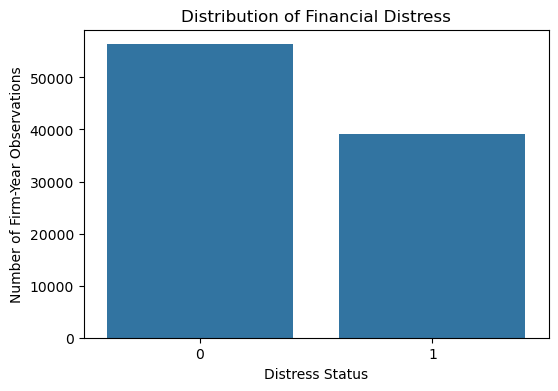

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="distress")

plt.title("Distribution of Financial Distress")
plt.xlabel("Distress Status")
plt.ylabel("Number of Firm-Year Observations")
plt.show()

In [18]:
distress_counts = df["distress"].value_counts()
distress_rates = df["distress"].value_counts(normalize=True) * 100

distress_summary = pd.DataFrame({
    "count": distress_counts,
    "percentage": distress_rates.round(2)
})

distress_summary

,count,percentage
distress,,
0,56349,58.96
1,39225,41.04


The distress label is defined at the firm-year level, not at the firm level. Therefore, the same firm can be classified as non-distressed in one year and distressed in another year. This structure is appropriate for our panel dataset because financial distress is a time-varying condition.

The distribution shows that 41.04% of firm-year observations are labeled as distressed, while 58.96% are non-distressed. This means that the target variable is not extremely imbalanced. However, the distress rate is relatively high compared to actual bankruptcy rates, which is expected because our label captures a technical financial distress proxy rather than legal bankruptcy.

## 3. Main Explanatory Variable: Leverage

Leverage is the main financial variable in our research question.  
We examine its distribution to understand how debt levels vary across firm-year observations and whether there are extreme values.

In [32]:
df["leverage"].describe()

count    95574.000000
mean         0.192436
std          0.243592
min          0.000000
25%          0.000000
50%          0.109740
75%          0.299475
max          1.320035
Name: leverage, dtype: float64

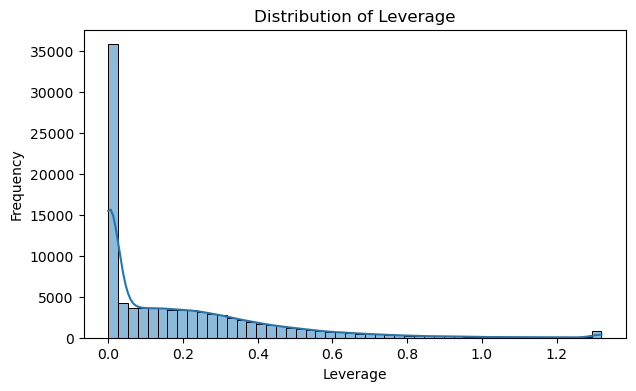

In [33]:
plt.figure(figsize=(7, 4))

sns.histplot(df["leverage"], bins=50, kde=True)

plt.title("Distribution of Leverage")
plt.xlabel("Leverage")
plt.ylabel("Frequency")
plt.show()

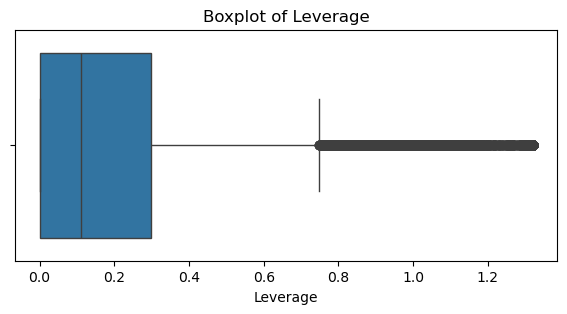

In [34]:
plt.figure(figsize=(7, 3))

sns.boxplot(x=df["leverage"])

plt.title("Boxplot of Leverage")
plt.xlabel("Leverage")
plt.show()

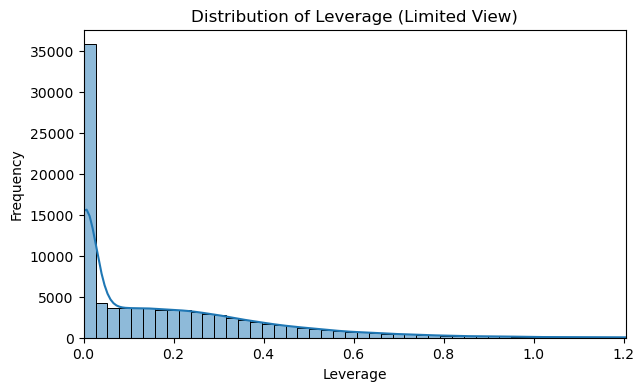

In [35]:
plt.figure(figsize=(7, 4))

sns.histplot(df["leverage"], bins=50, kde=True)

plt.title("Distribution of Leverage (Limited View)")
plt.xlabel("Leverage")
plt.ylabel("Frequency")
plt.xlim(df["leverage"].quantile(0.01), df["leverage"].quantile(0.99))
plt.show()

Leverage measures the extent to which a firm is financed by debt. In this project, leverage is the main explanatory variable because our research question asks whether higher debt levels are associated with financial distress.

The distribution of leverage is right-skewed. Most firm-year observations have relatively low leverage, while a smaller number of observations have much higher leverage values. The median leverage is 0.11, while the mean is 0.19, which suggests that high-leverage observations pull the average upward.

The boxplot also shows several high-leverage observations. These values may represent firms with unusually high debt levels, which are important for our project because highly leveraged firms may be more exposed to financial distress.

## 4. Leverage and Financial Distress

After examining leverage separately, we compare leverage between distressed and non-distressed firm-year observations.

This step helps us understand whether distressed observations tend to have higher leverage. However, this comparison is descriptive and does not prove causality.

In [4]:
leverage_by_distress = df.groupby("distress")["leverage"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

leverage_by_distress

,count,mean,median,std,min,max
distress,,,,,,
0,56349,0.191075,0.155846,0.187129,0.0,1.320035
1,39225,0.194392,0.027808,0.307032,0.0,1.320035


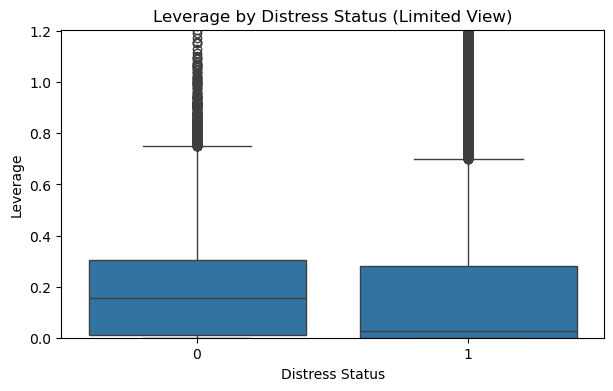

In [6]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="distress", y="leverage")

plt.title("Leverage by Distress Status (Limited View)")
plt.xlabel("Distress Status")
plt.ylabel("Leverage")
plt.ylim(
    df["leverage"].quantile(0.01),
    df["leverage"].quantile(0.99)
)
plt.show()

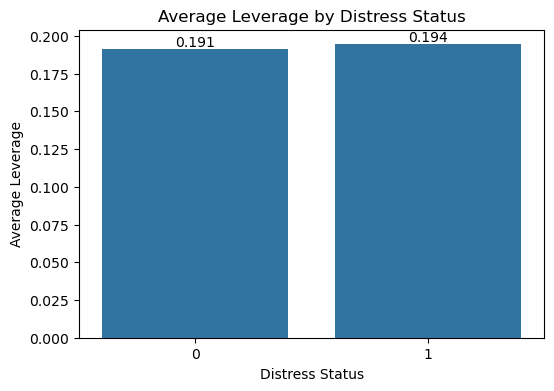

In [9]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(data=df, x="distress", y="leverage", errorbar=None)

plt.title("Average Leverage by Distress Status")
plt.xlabel("Distress Status")
plt.ylabel("Average Leverage")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.show()

In [8]:
leverage_by_distress

,count,mean,median,std,min,max
distress,,,,,,
0,56349,0.191075,0.155846,0.187129,0.0,1.320035
1,39225,0.194392,0.027808,0.307032,0.0,1.320035


The comparison between distressed and non-distressed observations shows that average leverage is only slightly higher for distressed firm-years. The mean leverage is 0.194 for distressed observations and 0.191 for non-distressed observations.

However, the median leverage is lower for distressed observations. This suggests that the relationship between leverage and distress is not straightforward in the descriptive statistics. Distressed observations have a higher standard deviation, meaning that leverage is more dispersed in the distressed group.

Therefore, leverage alone does not clearly separate distressed and non-distressed observations in the EDA. This motivates the use of supervised learning models with multiple financial ratios rather than relying only on leverage.

## 5. Financial Ratios by Distress Status

In addition to leverage, we compare other financial ratios across distressed and non-distressed firm-year observations.  
This helps us understand whether financially distressed firms differ in profitability, liquidity, solvency, and overall financial health.

These comparisons are descriptive and will later help motivate the supervised learning models.

In [10]:
financial_vars = [
    "leverage",
    "roa",
    "coverage",
    "current_ratio",
    "wcap_ratio",
    "asset_turnover",
    "retained_ratio",
    "solvency",
    "altman_z"
]

financial_vars

['leverage',
 'roa',
 'coverage',
 'current_ratio',
 'wcap_ratio',
 'asset_turnover',
 'retained_ratio',
 'solvency',
 'altman_z']

In [11]:
ratio_summary_by_distress = df.groupby("distress")[financial_vars].agg(["mean", "median", "std"])

ratio_summary_by_distress

leverage                           roa                      \
              mean    median       std      mean    median       std   
distress                                                               
0         0.191075  0.155846  0.187129  0.040224  0.047147  0.133255   
1         0.194392  0.027808  0.307032 -0.405395 -0.168421  0.698425   

           coverage                       current_ratio                      \
               mean     median        std          mean    median       std   
distress                                                                      
0         30.045661  11.085402  38.891573      2.495701  1.837724  2.562094   
1        -11.923320  -6.112028  38.411705      4.065419  2.078929  5.451512   

         wcap_ratio                     asset_turnover                      \
               mean    median       std           mean    median       std   
distress                                                                     
0          0.210260  0.177674  0.222919       1.091389  0.893036  0.775938   
1          0.226243  0.261558  0.508654       0.759880  0.521123  0.835569   

         retained_ratio                      solvency                      \
                   mean    median       std      mean    median       std   
distress                                                                    
0             -0.017425  0.158790  1.319675  0.504336  0.505441  0.241107   
1             -3.280657 -1.015705  6.064195  0.651061  0.477722  0.648211   

          altman_z                       
              mean    median        std  
distress                                 
0         2.704193  2.465921   2.885445  
1        -3.042606  0.109630  11.401603

In [14]:
mean_ratios_by_distress["Difference"] = (
    mean_ratios_by_distress["Distressed"] - mean_ratios_by_distress["Non-distressed"]
)

mean_ratios_by_distress.round(3)

,Non-distressed,Distressed,Difference
leverage,0.191,0.194,0.003
roa,0.040,-0.405,-0.446
coverage,30.046,-11.923,-41.969
current_ratio,2.496,4.065,1.570
wcap_ratio,0.210,0.226,0.016
asset_turnover,1.091,0.760,-0.332
retained_ratio,-0.017,-3.281,-3.263
solvency,0.504,0.651,0.147
altman_z,2.704,-3.043,-5.747


The financial ratio comparison shows that distressed firm-year observations have a much weaker financial profile than non-distressed observations.

The largest differences appear in profitability, interest coverage, retained earnings, asset turnover, and Altman Z-score. Distressed observations have substantially lower ROA, lower coverage, lower retained ratio, lower asset turnover, and much lower Altman Z-scores. These patterns are consistent with financial distress because distressed firms are generally less profitable, less able to cover obligations, and financially weaker overall.

Interestingly, average leverage is only slightly higher for distressed observations. This suggests that leverage alone does not clearly separate distressed and non-distressed firm-years in the descriptive analysis. Therefore, the supervised learning stage should use multiple financial ratios rather than relying only on leverage.

## 6. Correlation Matrix

We examine the correlation between the target variable and the main financial ratios.  
This helps identify which variables are most strongly associated with financial distress and whether some explanatory variables may contain overlapping information.

In [ ]:
corr_vars = [
    "distress",
    "leverage",
    "roa",
    "coverage",
    "current_ratio",
    "wcap_ratio",
    "asset_turnover",
    "retained_ratio",
    "solvency",
    "altman_z"
]

corr_matrix = df[corr_vars].corr()
#corr_matrix.round(3)


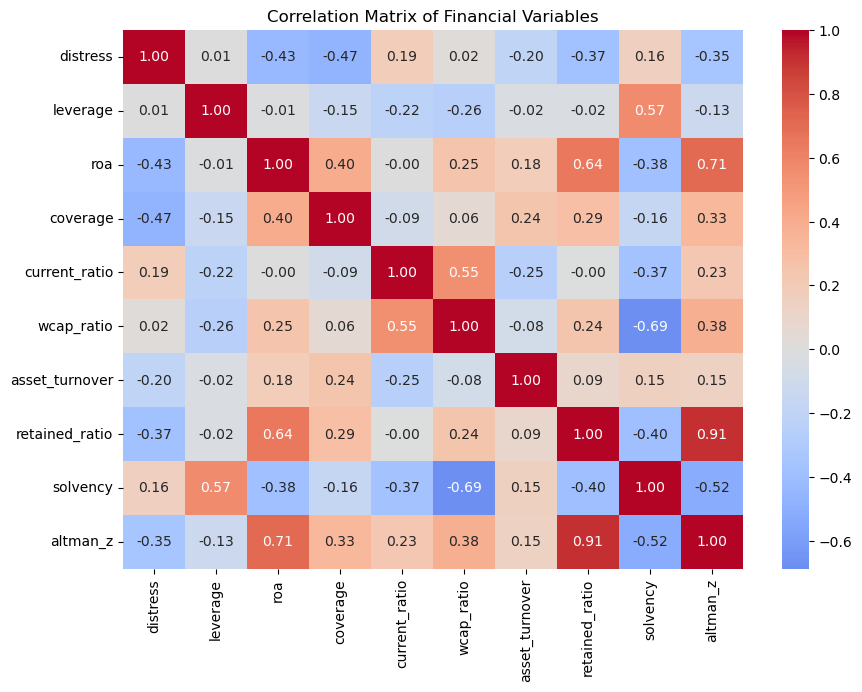

In [16]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Financial Variables")
plt.show()

In [18]:
distress_correlations = corr_matrix["distress"].drop("distress").sort_values()

distress_correlations.round(3)

coverage         -0.471
roa              -0.431
retained_ratio   -0.371
altman_z         -0.347
asset_turnover   -0.200
leverage          0.007
wcap_ratio        0.021
solvency          0.157
current_ratio     0.189
Name: distress, dtype: float64

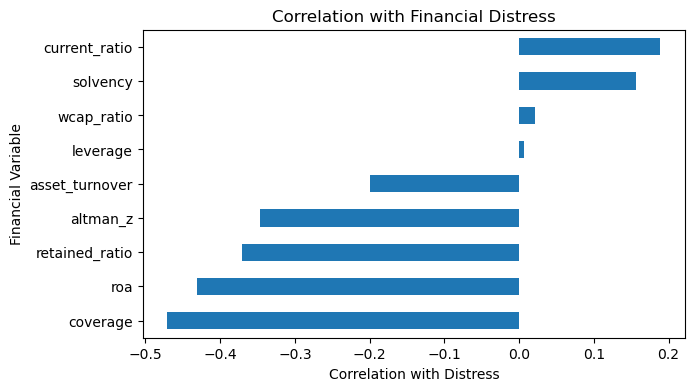

In [19]:
plt.figure(figsize=(7, 4))

distress_correlations.sort_values().plot(kind="barh")

plt.title("Correlation with Financial Distress")
plt.xlabel("Correlation with Distress")
plt.ylabel("Financial Variable")
plt.show()

The correlation analysis shows that financial distress has moderate negative correlations with coverage, ROA, retained ratio, and Altman Z-score. Among the variables, coverage and ROA show the strongest negative associations with distress.

This means that firm-year observations with higher profitability, better interest coverage, stronger retained earnings, and higher Altman Z-scores tend to be less likely to be classified as distressed.

However, these correlations are not close to -1, so they should not be interpreted as very strong or deterministic relationships. They only show descriptive linear associations.

## 7. Distress Patterns Over Time

Since the dataset is structured at the firm-year level, we examine whether the distress rate changes over time.

Because the number of observations differs by year, we compare yearly distress rates rather than raw distress counts. Since `distress` is a binary variable, the yearly mean of `distress` gives the percentage of firm-year observations classified as distressed in each year.

The observation count by year is also reported separately. This is important because yearly rates based on fewer observations may be less stable. In our dataset, however, each year still contains several thousand firm-year observations, so the yearly distress rates remain informative for descriptive analysis.

In [22]:
distress_by_year = df.groupby("fyear")["distress"].mean() * 100

distress_by_year

fyear
2000    48.440121
2001    43.688451
2002    39.419319
2003    36.870538
2004    37.085567
2005    37.881582
2006    38.230241
2007    39.693810
2008    37.133106
2009    32.845682
2010    33.725396
2011    35.923022
2012    38.196042
2013    41.089458
2014    42.857143
2015    42.395626
2016    41.474423
2017    43.172137
2018    49.318801
2019    51.532431
2020    50.432015
Name: distress, dtype: float64

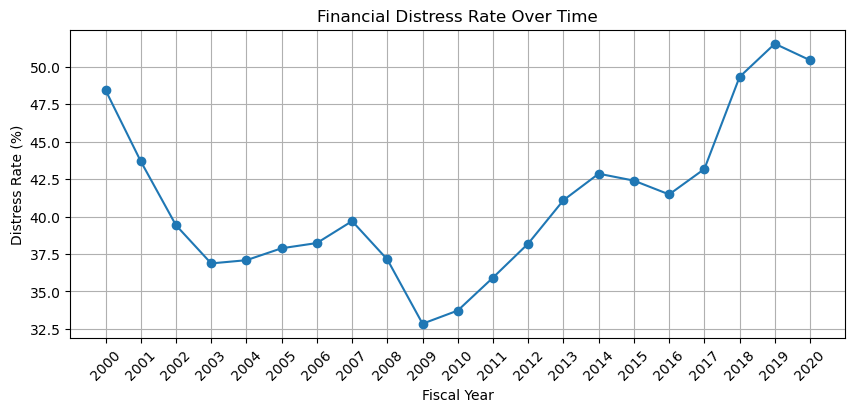

In [28]:
plt.figure(figsize=(10, 4))

years = distress_by_year.index.astype(int)

plt.plot(
    years,
    distress_by_year.values,
    marker="o"
)

plt.title("Financial Distress Rate Over Time")
plt.xlabel("Fiscal Year")
plt.ylabel("Distress Rate (%)")

plt.xticks(years, rotation=45)

plt.grid(True)
plt.show()

Although one might expect financial distress to increase around the 2008–2009 financial crisis, the distress rate in this dataset does not peak in 2009. This may be due to the specific construction of the distress proxy, which is based on accounting variables rather than legal bankruptcy or market-based distress. It may also reflect lagged effects, sample composition after cleaning, or the fact that the label captures next-year financial weakness rather than contemporaneous macroeconomic stress.

Therefore, the year pattern should be interpreted descriptively rather than as direct evidence of crisis effects.

In [24]:
observations_by_year = df["fyear"].value_counts().sort_index()

observations_by_year

fyear
2000    5962
2001    5585
2002    5373
2003    5183
2004    5037
2005    4881
2006    4656
2007    4507
2008    4395
2009    4238
2010    4166
2011    4209
2012    4346
2013    4259
2014    4130
2015    4024
2016    3988
2017    3991
2018    4037
2019    4209
2020    4398
Name: count, dtype: int64

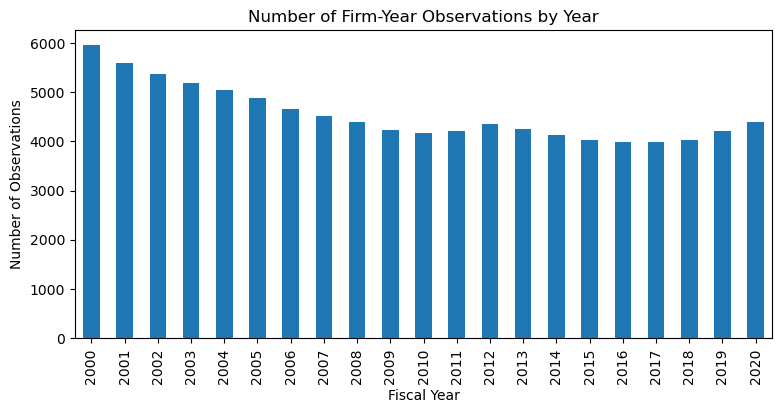

In [25]:
plt.figure(figsize=(9, 4))

observations_by_year.plot(kind="bar")

plt.title("Number of Firm-Year Observations by Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Observations")
plt.show()

The distress rate is not constant over time. It is relatively high in 2000, declines during the late 2000s and early 2010s, and increases again after 2017. The highest rates appear around 2019 and 2020.

Since we use distress rates instead of raw counts, these differences are not simply caused by some years having more observations. However, changes in sample composition and broader year-specific conditions may still affect the observed pattern. This suggests that year effects may be relevant in later supervised or causal analysis.

## 8. Industry-Level Distress Patterns

Financial distress may differ across industries because firms in different sectors have different business models, capital structures, and risk levels.

We examine distress rates by industry using the `sich` industry code. Since some industries may have very few observations, we focus only on industries with at least 100 firm-year observations.

To make the results interpretable, we manually map the top SIC codes to industry names using official SIC descriptions from the SEC SIC code list and SIC manual references.

In [35]:
industry_distress_summary = df.groupby("sich").agg(
    observations=("distress", "count"),
    distressed_count=("distress", "sum"),
    distress_rate=("distress", "mean")
)

industry_distress_summary["distress_rate"] = (
    industry_distress_summary["distress_rate"] * 100
)

industry_distress_summary = industry_distress_summary.sort_values(
    "distress_rate", ascending=False
)

industry_distress_summary.round(2)

,observations,distressed_count,distress_rate
sich,,,
6311.0,5,5,100.0
6792.0,1,1,100.0
6141.0,5,5,100.0
8600.0,1,1,100.0
6510.0,2,2,100.0
...,...,...,...
4941.0,3,0,0.0
6361.0,10,0,0.0
6321.0,3,0,0.0


In [ ]:
#filter industries with enough observations

industry_filtered = industry_distress_summary[
    industry_distress_summary["observations"] >= 100
]

industry_filtered.head(15).round(2)

,observations,distressed_count,distress_rate
sich,,,
2836.0,5570,5186,93.11
9995.0,348,310,89.08
1090.0,125,102,81.60
2835.0,971,740,76.21
2834.0,4074,2721,66.79
8731.0,568,376,66.20
3845.0,1641,1050,63.99
7310.0,255,160,62.75
1000.0,615,384,62.44


In [36]:
sic_labels = {
    2836: "Biological Products",
    9995: "Non-operating Establishments",
    1090: "Miscellaneous Metal Ores",
    2835: "In Vitro & In Vivo Diagnostic Substances",
    2834: "Pharmaceutical Preparations",
    8731: "Commercial Physical and Biological Research",
    3845: "Electromedical Equipment",
    7310: "Advertising",
    1000: "Metal Mining",
    3661: "Telephone and Telegraph Apparatus",
    3841: "Surgical and Medical Instruments",
    1040: "Gold and Silver Ores",
    3669: "Communications Equipment, NEC",
    3576: "Computer Communications Equipment",
    4899: "Communications Services, NEC"
}

In [37]:
industry_filtered_labeled = industry_filtered.copy()

industry_filtered_labeled["industry_name"] = (
    industry_filtered_labeled.index.astype(int).map(sic_labels)
)

industry_filtered_labeled["industry_label"] = (
    industry_filtered_labeled.index.astype(int).astype(str)
    + " - "
    + industry_filtered_labeled["industry_name"].fillna("Unknown")
)

industry_filtered_labeled.head(15).round(2)

,observations,distressed_count,distress_rate,industry_name,industry_label
sich,,,,,
2836.0,5570,5186,93.11,Biological Products,2836 - Biological Products
9995.0,348,310,89.08,Non-operating Establishments,9995 - Non-operating Establishments
1090.0,125,102,81.60,Miscellaneous Metal Ores,1090 - Miscellaneous Metal Ores
2835.0,971,740,76.21,In Vitro & In Vivo Diagnostic Substances,2835 - In Vitro & In Vivo Diagnostic Substances
2834.0,4074,2721,66.79,Pharmaceutical Preparations,2834 - Pharmaceutical Preparations
8731.0,568,376,66.20,Commercial Physical and Biological Research,8731 - Commercial Physical and Biological Rese...
3845.0,1641,1050,63.99,Electromedical Equipment,3845 - Electromedical Equipment
7310.0,255,160,62.75,Advertising,7310 - Advertising
1000.0,615,384,62.44,Metal Mining,1000 - Metal Mining


In [38]:
top_industries_table = industry_filtered_labeled.head(15)[
    ["industry_name", "observations", "distressed_count", "distress_rate"]
]

top_industries_table.round(2)

,industry_name,observations,distressed_count,distress_rate
sich,,,,
2836.0,Biological Products,5570,5186,93.11
9995.0,Non-operating Establishments,348,310,89.08
1090.0,Miscellaneous Metal Ores,125,102,81.60
2835.0,In Vitro & In Vivo Diagnostic Substances,971,740,76.21
2834.0,Pharmaceutical Preparations,4074,2721,66.79
8731.0,Commercial Physical and Biological Research,568,376,66.20
3845.0,Electromedical Equipment,1641,1050,63.99
7310.0,Advertising,255,160,62.75
1000.0,Metal Mining,615,384,62.44


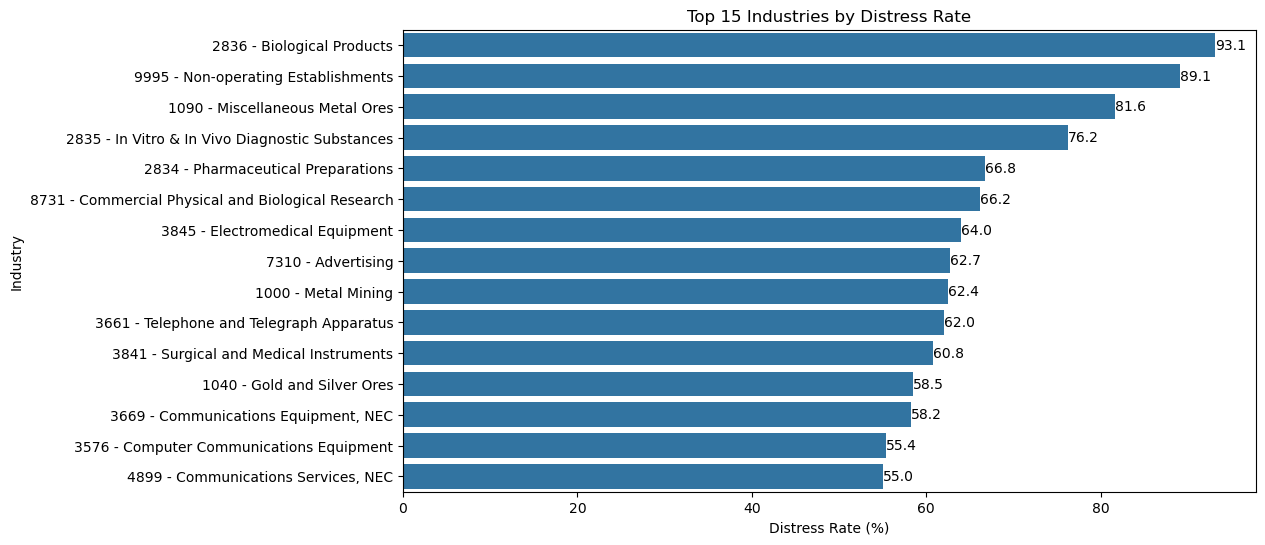

In [39]:
top_industries_plot = industry_filtered_labeled.head(15).reset_index()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=top_industries_plot,
    x="distress_rate",
    y="industry_label",
    orient="h"
)

plt.title("Top 15 Industries by Distress Rate")
plt.xlabel("Distress Rate (%)")
plt.ylabel("Industry")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.show()

The industry-level analysis shows that financial distress is not evenly distributed across sectors. After mapping SIC codes to industry names using official SIC descriptions, the highest distress rates are concentrated in Biological Products, In Vitro & In Vivo Diagnostic Substances, Pharmaceutical Preparations, Commercial Physical and Biological Research, Electromedical Equipment, and other medical or research-related industries.

This pattern suggests that life sciences, biotechnology, pharmaceuticals, and medical research firms are more frequently classified as distressed in our cleaned dataset. This may be reasonable because these sectors often face high R&D costs, long product development cycles, uncertain revenues, and delayed profitability.

Mining-related industries also appear among the high-distress sectors, such as Miscellaneous Metal Ores, Metal Mining, and Gold and Silver Ores. These industries may be more exposed to capital intensity and commodity price volatility.

Communication-related industries, including Telephone and Telegraph Apparatus, Communications Equipment, Computer Communications Equipment, and Communications Services, also appear in the top 15. This suggests that distress risk may vary meaningfully across industry groups.

The category `9995 - Non-operating Establishments` also has a high distress rate, but it should be interpreted carefully because it may reflect a special classification rather than a standard operating industry.

Overall, these results suggest that industry effects may be important in later supervised learning or causal analysis. We therefore should not treat all firms as if they face the same baseline distress risk across sectors.

SIC code names were matched using official SIC descriptions from the SEC Standard Industrial Classification code list and SIC manual references.

## 9. EDA Summary and Link to Next Steps

The exploratory data analysis provides several important insights for the next stages of the project.

First, the cleaned dataset contains 95,574 firm-year observations and 11,402 unique firms. The data is structured as panel data, meaning that the same firm can appear in multiple fiscal years. The distress variable is therefore interpreted at the firm-year level, not as a fixed firm-level label.

Second, the distress variable is not extremely imbalanced. Around 41% of firm-year observations are classified as distressed, while around 59% are non-distressed. However, this distress label should be interpreted as a financial distress proxy rather than legal bankruptcy.

Third, leverage is the main explanatory variable in our research question, but the descriptive analysis shows that leverage alone does not clearly separate distressed and non-distressed observations. Average leverage is only slightly higher among distressed observations, and its correlation with distress is close to zero.

Fourth, other financial ratios show clearer differences. Distressed observations have lower ROA, lower coverage, lower retained ratio, lower asset turnover, and lower Altman Z-scores. This suggests that financial distress is better understood as a multidimensional financial condition rather than the result of leverage alone.

Fifth, distress rates vary across years and industries. This suggests that year-specific conditions and industry effects may be relevant for later modeling. In particular, some biotechnology, pharmaceutical, medical research, mining, and communications-related industries show higher distress rates.

Overall, the EDA motivates the supervised learning stage: instead of using only leverage, we should use multiple financial ratios to predict financial distress. It also motivates the causal analysis stage: because distress differs across financial characteristics, years, and industries, these factors may need to be considered when discussing confounding and causal assumptions.

In [44]:
eda_key_findings = pd.DataFrame({
    "Finding": [
        "Dataset size",
        "Distress rate",
        "Leverage-distress relationship",
        "Important financial indicators",
        "Time and industry variation"
    ],
    "EDA result": [
        "95,574 firm-year observations and 11,402 unique firms",
        "Around 41% of observations are classified as distressed",
        "Leverage alone does not clearly separate distressed and non-distressed observations",
        "ROA, coverage, retained ratio, asset turnover, and Altman Z-score differ more strongly by distress status",
        "Distress rates vary across fiscal years and SIC industries"
    ],
    "Implication": [
        "Panel-data structure should be considered",
        "Classification models should evaluate more than accuracy",
        "Supervised learning should include multiple ratios, not only leverage",
        "These variables may be useful predictors in supervised learning",
        "Year and industry may be relevant controls or contextual variables"
    ]
})

eda_key_findings

,Finding,EDA result,Implication
0,Dataset size,"95,574 firm-year observations and 11,402 uniqu...",Panel-data structure should be considered
1,Distress rate,Around 41% of observations are classified as d...,Classification models should evaluate more tha...
2,Leverage-distress relationship,Leverage alone does not clearly separate distr...,Supervised learning should include multiple ra...
3,Important financial indicators,"ROA, coverage, retained ratio, asset turnover,...",These variables may be useful predictors in su...
4,Time and industry variation,Distress rates vary across fiscal years and SI...,Year and industry may be relevant controls or ...
